# How Can a Wellness Technology Company Play It Smart?

**Bellabeat — Capstone for Google Data Analytics Professional Certificate**

## The Challenge

Bellabeat, a high-tech wellness company focused on women's health, wants to expand its market position in the global smart device industry. By analyzing how consumers use non-Bellabeat smart devices, we can uncover patterns and opportunities to refine Bellabeat's marketing strategy and product offerings.

**Key Questions:**
- What behavioral patterns emerge from smart device usage data?
- How can these insights inform targeted marketing campaigns?
- Which product features should Bellabeat emphasize to maximize user engagement?

## The Data

**Source:** [FitBit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit) (CC0: Public Domain)
- **33 users** (activity dataset) and **24 users** (sleep dataset) who consented to share personal tracker data
- **Daily activity metrics:** steps, distance, intensity levels, calories
- **Sleep tracking:** duration, efficiency, time in bed
- **Credibility:** Kaggle usability score of 9.41

## Setup & Data Loading

In [1]:
# Install packages only if missing, then load libraries (quietly)
pkg <- function(x) { 
    if (!requireNamespace(x, quietly = TRUE))
        install.packages(x, repos = 'https://cloud.r-project.org')
}
pkg('tidyverse')
pkg('lubridate')
pkg('conflicted')
library(conflicted)
conflict_prefer('filter', 'dplyr')
conflict_prefer('lag', 'dplyr')
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(lubridate))

# Load datasets
daily_activity <- read.csv("../data/raw/fitabase_4.12.16-5.12.16/dailyActivity_merged.csv")
sleep_day <- read.csv("../data/raw/fitabase_4.12.16-5.12.16/sleepDay_merged.csv")

# Quick data overview
cat("Daily Activity:", nrow(daily_activity),
    "observations from", n_distinct(daily_activity$Id), "users\n")
cat("Sleep Data:", nrow(sleep_day), "observations from", n_distinct(sleep_day$Id), "users\n")

[conflicted] Will prefer dplyr::filter over any other package.
[conflicted] Will prefer dplyr::lag over any other package.


Daily Activity: 940 observations from 33 users
Sleep Data: 413 observations from 24 users


## Initial Discovery: The Sedentary Lifestyle Problem

A first look at the data reveals a striking pattern that presents both a challenge and an opportunity for Bellabeat.

Average daily steps: 7638 
Average sedentary time: 16.5 hours per day



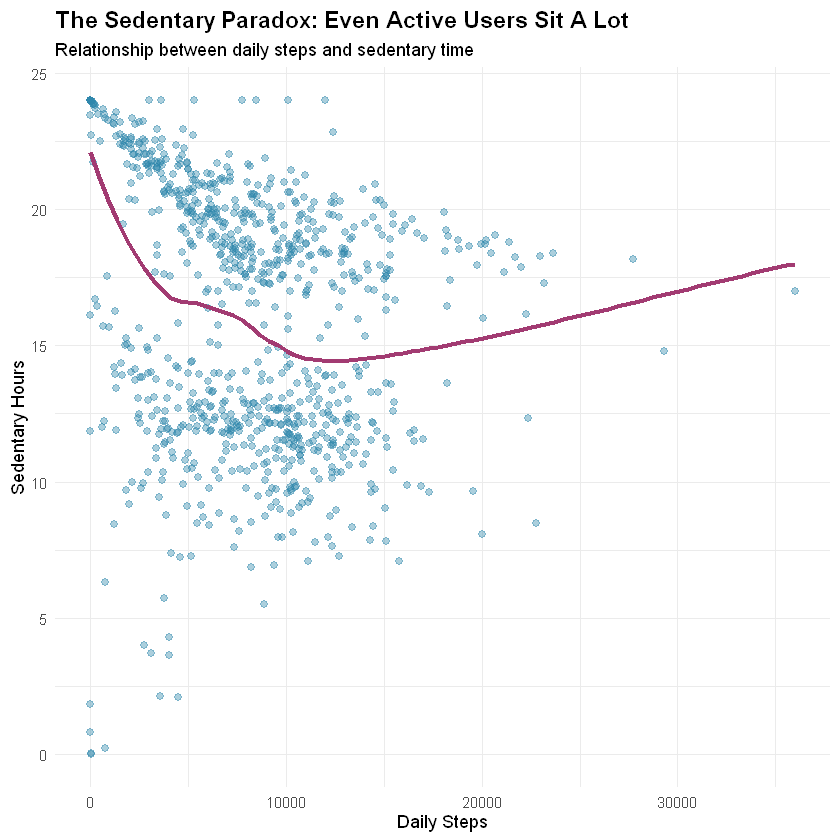

In [2]:
# Calculate key metrics
avg_steps <- mean(daily_activity$TotalSteps)
avg_sedentary_hours <- mean(daily_activity$SedentaryMinutes) / 60

cat("Average daily steps:", round(avg_steps), "\n")
cat("Average sedentary time:", round(avg_sedentary_hours, 1), "hours per day\n\n")

# Visualize the relationship
ggplot(daily_activity, aes(x = TotalSteps, y = SedentaryMinutes / 60)) +
  geom_point(alpha = 0.4, color = "#2E86AB", size = 2) +
  geom_smooth(
    method = "loess", se = FALSE, color = "#A23B72",
    linewidth = 1.2, formula = y ~ x) +
  labs(
    title = "The Sedentary Paradox: Even Active Users Sit A Lot",
    subtitle = "Relationship between daily steps and sedentary time",
    x = "Daily Steps",
    y = "Sedentary Hours"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

**Key Insight:** Users average **16.5 hours of sedentary time daily**, even those hitting 10,000+ steps. This suggests that step count alone doesn't tell the full story—people can be both "active" AND sedentary.

**Marketing Opportunity:** Position Bellabeat's movement reminders and activity tracking as essential tools for breaking up long periods of sitting, not just counting steps.

## Activity Patterns: Three Distinct User Segments

activity_segment,count,avg_steps,avg_calories
<chr>,<int>,<dbl>,<dbl>
Moderately Active (5-10k steps),334,7466,2355
Highly Active (10k+ steps),303,13337,2744
Low Activity (<5k steps),303,2128,1807


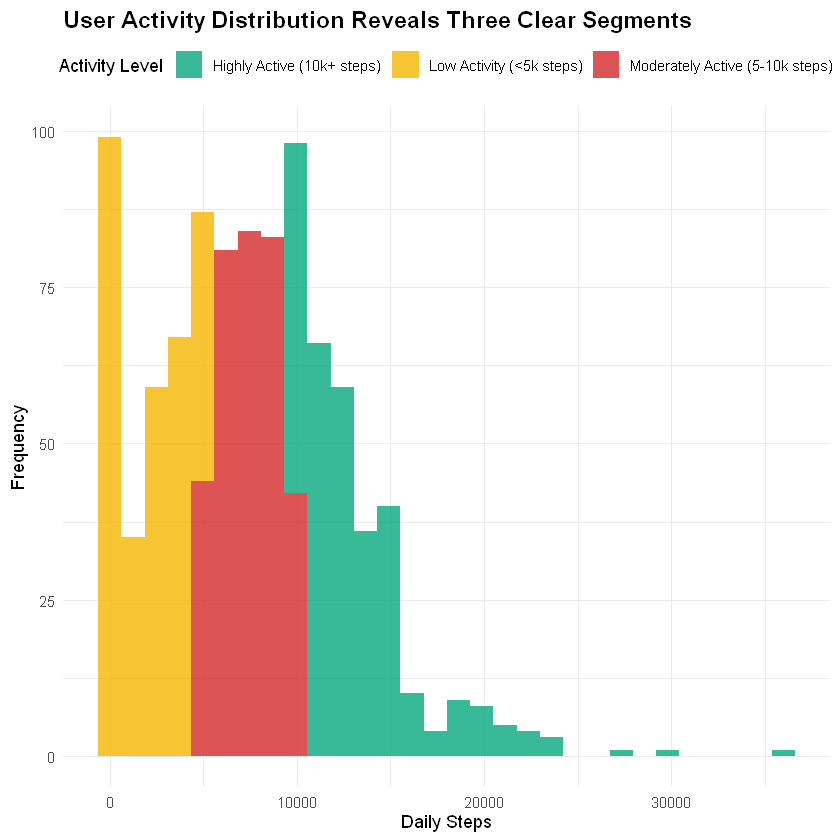

In [3]:
# Segment users by activity level
daily_activity <- daily_activity %>%
  mutate(
    activity_segment = case_when(
      TotalSteps >= 10000 ~ "Highly Active (10k+ steps)",
      TotalSteps >= 5000 ~ "Moderately Active (5-10k steps)",
      TRUE ~ "Low Activity (<5k steps)"
    )
  )

# Count users in each segment
segment_distribution <- daily_activity %>%
  group_by(activity_segment) %>%
  summarise(
    count = n(),
    avg_steps = round(mean(TotalSteps)),
    avg_calories = round(mean(Calories))
  ) %>%
  arrange(desc(count))

# Visualize distribution
ggplot(daily_activity, aes(x = TotalSteps, fill = activity_segment)) +
  geom_histogram(bins = 30, alpha = 0.8) +
  scale_fill_manual(values = c("#06A77D", "#F5B700", "#D62828")) +
  labs(
    title = "User Activity Distribution Reveals Three Clear Segments",
    x = "Daily Steps",
    y = "Frequency",
    fill = "Activity Level"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    legend.position = "top"
  )

segment_distribution

**Marketing Strategy:** Create **segment-specific messaging**:
- **Highly Active:** "Track your peak performance" - emphasize advanced metrics
- **Moderately Active:** "Small steps, big progress" - encourage consistency
- **Low Activity:** "Start where you are" - focus on achievable goals and gentle nudges

## Sleep Analysis: Quality Over Quantity

Average sleep duration: 7 hours
Average sleep efficiency: 91.7 %



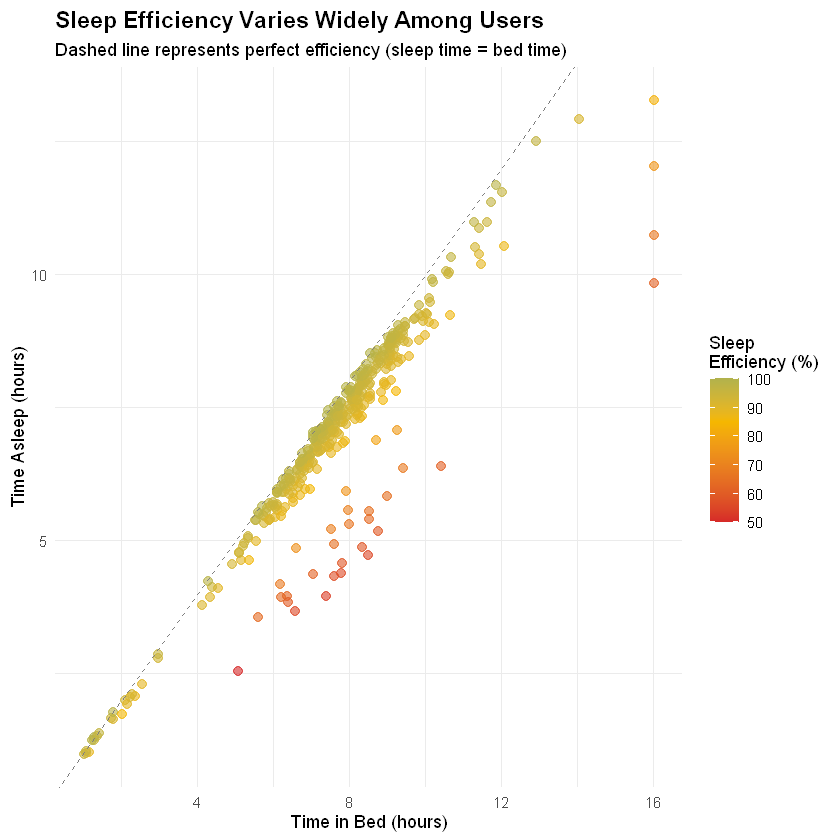

In [4]:
# Calculate sleep efficiency
sleep_day <- sleep_day %>%
  mutate(
    sleep_efficiency = (TotalMinutesAsleep / TotalTimeInBed) * 100,
    sleep_hours = TotalMinutesAsleep / 60
  )

# Summary statistics
cat("Average sleep duration:", round(mean(sleep_day$sleep_hours), 1), "hours\n")
cat("Average sleep efficiency:", round(mean(sleep_day$sleep_efficiency), 1), "%\n\n")

# Visualize sleep efficiency
ggplot(sleep_day, aes(x = TotalTimeInBed / 60, y = TotalMinutesAsleep / 60)) +
  geom_point(aes(color = sleep_efficiency), alpha = 0.6, size = 2.5) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  scale_color_gradient2(
    low = "#D62828",
    mid = "#F5B700", 
    high = "#06A77D",
    midpoint = 85,
    name = "Sleep\nEfficiency (%)"
  ) +
  labs(
    title = "Sleep Efficiency Varies Widely Among Users",
    subtitle = "Dashed line represents perfect efficiency (sleep time = bed time)",
    x = "Time in Bed (hours)",
    y = "Time Asleep (hours)"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

**Key Finding:** Many users spend significantly more time in bed than actually sleeping, indicating **sleep efficiency problems**. Points far below the diagonal line represent users losing 30+ minutes to restlessness, difficulty falling asleep, or mid-sleep wakings.

**Product Opportunity:** Develop **sleep environment optimization features** - track factors like room temperature, light, noise, and suggest personalized improvements to increase sleep efficiency.

## Statistical Summary: What the Numbers Tell Us

In [5]:
# Activity summary
cat("=== ACTIVITY METRICS ===\n")
daily_activity %>%
  select(TotalSteps, TotalDistance, Calories, SedentaryMinutes, 
         VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes) %>%
  summary()

cat("\n=== SLEEP METRICS ===\n")
sleep_day %>%
  select(TotalMinutesAsleep, TotalTimeInBed, sleep_efficiency) %>%
  summary()

=== ACTIVITY METRICS ===


   TotalSteps    TotalDistance       Calories    SedentaryMinutes
 Min.   :    0   Min.   : 0.000   Min.   :   0   Min.   :   0.0  
 1st Qu.: 3790   1st Qu.: 2.620   1st Qu.:1828   1st Qu.: 729.8  
 Median : 7406   Median : 5.245   Median :2134   Median :1057.5  
 Mean   : 7638   Mean   : 5.490   Mean   :2304   Mean   : 991.2  
 3rd Qu.:10727   3rd Qu.: 7.713   3rd Qu.:2793   3rd Qu.:1229.5  
 Max.   :36019   Max.   :28.030   Max.   :4900   Max.   :1440.0  
 VeryActiveMinutes FairlyActiveMinutes LightlyActiveMinutes
 Min.   :  0.00    Min.   :  0.00      Min.   :  0.0       
 1st Qu.:  0.00    1st Qu.:  0.00      1st Qu.:127.0       
 Median :  4.00    Median :  6.00      Median :199.0       
 Mean   : 21.16    Mean   : 13.56      Mean   :192.8       
 3rd Qu.: 32.00    3rd Qu.: 19.00      3rd Qu.:264.0       
 Max.   :210.00    Max.   :143.00      Max.   :518.0       


=== SLEEP METRICS ===


 TotalMinutesAsleep TotalTimeInBed  sleep_efficiency
 Min.   : 58.0      Min.   : 61.0   Min.   : 49.84  
 1st Qu.:361.0      1st Qu.:403.0   1st Qu.: 91.22  
 Median :433.0      Median :463.0   Median : 94.31  
 Mean   :419.5      Mean   :458.6   Mean   : 91.68  
 3rd Qu.:490.0      3rd Qu.:526.0   3rd Qu.: 96.07  
 Max.   :796.0      Max.   :961.0   Max.   :100.00  

## Key Insights & Strategic Recommendations

### 🎯 Core Findings

1. **The Activity Paradox:** Users can be both active (meeting step goals) AND highly sedentary (16+ hours sitting). Traditional metrics miss this nuance.

2. **Three Distinct Markets:** User behavior clusters into clear segments requiring different messaging and features.

3. **Sleep Quality Gap:** Average sleep duration (~7 hours) is acceptable, but poor efficiency means users could feel more rested with the same time investment.

### 💡 Actionable Marketing Strategies

**1. "Beyond Steps" Campaign**
- Target: All user segments
- Message: "Your fitness tracker counts steps. Bellabeat transforms your entire day."
- Focus: Highlight holistic health tracking—movement patterns throughout the day, not just total steps

**2. Segment-Specific Onboarding**
- Customize app experience based on initial activity assessment
- Highly Active → Advanced analytics, performance trends, competitive challenges
- Moderately Active → Progress tracking, streak rewards, achievable milestones
- Low Activity → Gentle reminders, micro-goals, educational content

**3. "Sleep Smarter" Feature Set**
- Emphasize sleep efficiency metrics over just duration
- Market Bellabeat's ability to identify environmental factors affecting sleep quality
- Create shareable "Sleep Score" to encourage engagement

### 🚀 Product Development Priorities

1. **Sedentary Break Alerts:** Smart notifications that learn user patterns and suggest optimal movement breaks
2. **Sleep Environment Monitoring:** Partner features or integrations for temperature, light, and sound tracking
3. **Personalized Insights Engine:** Use ML to provide segment-appropriate recommendations

### 📊 Success Metrics

- Increase in average daily active minutes (not just steps)
- Improved sleep efficiency scores among users
- Higher engagement rates with segment-tailored content
- Growth in Bellabeat membership conversions from free users

## Limitations & Next Steps

**Data Limitations:**
- Small sample size (30 users) may not fully represent Bellabeat's target demographic
- One-month observation window limits understanding of long-term behavior patterns
- No demographic data (age, gender, lifestyle) prevents deeper segmentation
- Missing context on device wearing compliance and data accuracy

**Recommended Follow-Up Analysis:**
1. **Survey existing Bellabeat users** to validate findings and gather demographic context
2. **Conduct A/B testing** on segment-specific messaging to measure engagement impact
3. **Analyze seasonal variations** in activity and sleep patterns for better feature timing
4. **Investigate correlations** between sleep efficiency and next-day activity levels

---

*Analysis completed using R (tidyverse, ggplot2, lubridate) | Data: FitBit Fitness Tracker Dataset (Kaggle)*